In [1]:
import os
import geopandas as gpd
from matplotlib import pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib as mpl
import numpy as np
from pathlib import Path
import json

In [2]:
datadir = Path('/home/alex/class/6C85-nb/data/')
path_parcels   = os.path.join(datadir,'geog/Metro Boston (MAPC Region) Parcel/metro_boston_parcel.csv')
path_eviction  = os.path.join(datadir,'Exploring corporate owners & evictions/Eviction (2020-2023) + Owner Occupancy (2020) + Corporate Ownership (2020) + Residential Sales Data + Census Track (2020) /Eviction (2020-2023) + Owner Occupancy (2020) + Corporate Ownership (2020) + Residential Sales + Census (2010).csv')
path_zips      = os.path.join(datadir,'geog/Boston Neighborhoods/Boston_Neighborhoods_Zipcodes.csv')

geopath_hoods  = os.path.join(datadir,'geog/Boston Neighborhoods/Boston_Neighborhoods.geojson.json')
geopath_geoids = os.path.join(datadir,'geog/MAPC Region Census/MAPC region - Census tracts 2020/2020 Census Tracts MAPC Region.geojson')

## Readme

#### Dataframes (no inherent geographic data)
- `df_parcels` Land parcel data (~100k points). This is where I calculate area per unit and purchase price.
    - This is very roughly calculated per unit. Ex: price per unit = (parcel price)/(num. residential units)
- `df_eviction` Eviction data per neighborhood
- `df_zips` Simple dataframe listing zip codes and associated neighborhoods.

#### Geodataframes (contains geographic data)
- `gpdf_geoids` Contains census tract geoids
- `gpdf_hoods` Contains neighborhood boundaries


#### Workflow 1: Map Parcels' Unit Prices to Neighborhood
1. From `df_parcels`, calculate unit price = (parcel price)/(num. residential units)
2. Divide price by 20*12 for a naive monthly payment (assumption 20yr term, 0% interest...)
3. Use ZIP code to collect by neighborhood (dict_zip2hood)
4. Using `gpdf_hoods`, plot price of each parcel, by neighborhood (clusters)
5. Using `gpdf_hoods`, average prices by neighborhood (choropleth)

#### Workflow 2: Map Eviction Data to Neighborhood (WIP)
1. Map `df_eviction['geoid']` to `gpdf_geoids['geometry']`
2. Collect by neighborhood by intersecting each geoid with `gpdf_hoods`

# **LOAD: Dataframes**

In [3]:
# PARCEL DATA (has zip code)
df_parcels = pd.read_csv(path_parcels, dtype='unicode')
len(df_parcels)
print(df_parcels.columns)
df_parcels.head()

Index(['fid', 'LOC_ID', 'TOWN_ID', 'PROP_ID', 'BLDG_VAL', 'LAND_VAL',
       'OTHER_VAL', 'TOTAL_VAL', 'FY', 'LOT_SIZE', 'LS_DATE', 'LS_PRICE_S',
       'LS_PRICE_L', 'USE_CODE_L', 'USE_CODE_M', 'LUC_Assign_L',
       'LUC_Assign_M', 'L3_Description_L', 'L3_Description_M', 'USE_DESC_L',
       'USE_DESC_M', 'USE_CODE_SYMB', 'SITE_ADDR_L', 'SITE_ADDR_M', 'ADDR_NUM',
       'FULL_STR', 'LOCATION', 'CITY', 'ZIP', 'OWN_ADDR', 'OWN_CITY',
       'OWN_STATE', 'OWN_ZIP', 'OWN_CO', 'LS_BOOK', 'LS_PAGE', 'REG_ID',
       'ZONING_L', 'ZONING_M', 'YEAR_BUILT', 'BLD_AREA', 'UNITS',
       'UNITS_CONDO', 'RES_AREA', 'STYLE', 'NUM_ROOMS', 'LOT_UNITS', 'STORIES',
       'MA_PROP_ID', 'CAMA_ID', 'LOT_SIZE_GIS', 'sum_address_points',
       'imputed_units', 'delta_address', 'delta_assessor', 'FAR', 'BLDGV_PSF',
       'BLDLND_RAT', 'municipal'],
      dtype='str')


,fid,LOC_ID,TOWN_ID,PROP_ID,BLDG_VAL,LAND_VAL,OTHER_VAL,TOTAL_VAL,FY,LOT_SIZE,...,CAMA_ID,LOT_SIZE_GIS,sum_address_points,imputed_units,delta_address,delta_assessor,FAR,BLDGV_PSF,BLDLND_RAT,municipal
0,1,F_703378_2871841,208,15_54_87_15,479100,191200,2200,672500,2023,17703,...,104111,17603.9202327264,NaN,1,NaN,-1,0.270280706632304,100.693568726356,2.51725941422594,Norfolk
1,2,F_697526_2874354,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Norfolk
2,3,F_692852_2864290,208,2_5_1,0,177300,0,177300,2023,21780,...,15,27126.5227574773,NaN,0,NaN,0,0,NaN,0,Norfolk
3,4,F_703472_2868437,208,14_51_1,3351000,428500,91600,3871100,2023,69696,...,1899,154789.117502833,2,0,2,0,0.158047286493201,136.976782210595,8.0340723453909,Norfolk
4,5,F_689174_2872544,208,4_21_1,490200,169700,3900,663800,2023,14967,...,352,18137.5745077556,1,1,0,-1,0.19032313270575,142.004634994206,2.91160872127283,Norfolk


In [4]:
# EVICTION DATA (has GEOID)
df_eviction = pd.read_csv(path_eviction)
len(df_eviction)
print(df_eviction.columns)
df_eviction.head()

Index(['GEOID', '2020_eviction', '2021_eviction', '2022_eviction',
       '2023_eviction', 'own_occ_rate', 'corp_own_rate', 'median_yearbuilt',
       'median_price', 'median_prslpr', 'mortgage', 'median_totrooms',
       'median_bathrooms', 'median_bedrooms', 'median_lotsize',
       'median_intersf', 'median_flip_horizon', 'median_price_diff',
       'median_price_diff_pch', 'median_lasqbin', 'mean_month_horizon',
       'buyer_llc_ind_sum', 'buyer_bus_ind_sum', 'buyer_trst_ind_sum',
       'buyer_bnk_ind_sum', 'buyer_gse_ind_sum', 'buyer_gov_ind_sum',
       'seller_llc_ind_sum', 'seller_llp_ind_sum', 'seller_bus_ind_sum',
       'seller_trst_ind_sum', 'seller_bnk_ind_sum', 'seller_gse_ind_sum',
       'seller_gov_ind_sum', 'flip_ind_sum', 'buy_side_flip_sum',
       'sell_side_flip_sum', 'restype_R1F_sum', 'sum_institutional_investor',
       'sum_large_investor', 'sum_medium_investor', 'sum_non_investor',
       'sum_small_investor', 'sum_non_small_llc_investor',
       'sum_small

,GEOID,2020_eviction,2021_eviction,2022_eviction,2023_eviction,own_occ_rate,corp_own_rate,median_yearbuilt,median_price,median_prslpr,...,nfhh5,nfhh6,nfhh7o,acs_year,mhi,mhi_me,o_mhi,o_mhi_me,r_mhi,r_mhi_me
0,25017350103,5.0,27.0,54.0,40.0,0.0,0.0,1926.5,385250.0,0.0,...,3.0,0.0,1.0,2007-11,66289.0,14867.0,67946.0,24272.0,62500.0,17116.0
1,25017351500,6.0,7.0,16.0,15.0,0.0,0.0,1920.0,316000.0,0.0,...,9.0,3.0,0.0,2007-11,46088.0,8581.0,73625.0,36340.0,36193.0,12570.0
2,25017373100,1.0,6.0,4.0,5.0,0.0,0.0,1910.0,453750.0,142625.0,...,3.0,4.0,1.0,2007-11,77575.0,20060.0,103478.0,37193.0,63813.0,11158.0
3,25017373600,2.0,0.0,4.0,0.0,0.0,0.0,1945.0,537500.0,165000.0,...,4.0,2.0,4.0,2007-11,137460.0,45902.0,213843.0,31448.0,74085.0,44797.0
4,25021400600,4.0,1.0,3.0,2.0,0.0,1.0,1915.0,480000.0,194500.0,...,15.0,2.0,0.0,2007-11,138506.0,37597.0,162422.0,16057.0,55341.0,27027.0


In [5]:
df_zips = pd.read_csv(path_zips)
print(len(df_zips))
print(df_zips.columns)
df_zips

35
Index(['Zip Code', 'Neighborhood'], dtype='str')


,Zip Code,Neighborhood
0,2134,Allston
1,2116,Back Bay
2,2114,Beacon Hill
3,2108,Beacon Hill
4,2135,Brighton
5,2113,Downtown
6,2109,Downtown
7,2110,Downtown
8,2199,Downtown
9,2203,Downtown


# **LOAD: Geopandas Dataframes**

In [6]:
# MUNICIPALITIES
#gpdf = gpd.read_file(os.path.join(datadir,'geog/Metro Boston (MAPC Region) municipalities/mapc_municipalities.geojson'))
#print(len(gpdf))
#print(gpdf.columns.unique())
#gpdf.head()

In [7]:
# CENSUS TRACTS (has GEOID)
#gpdf2 = gpd.read_file(os.path.join(datadir,'geog/MAPC Region Census/MAPC region - Towns/mapc_region_towns_w_population.geojson'))
#print(len(gpdf2))
#print(gpdf2.columns.unique())
#gpdf2.head()

In [8]:
# MAPC REGION
gpdf_geoids = gpd.read_file(geopath_geoids)
len(gpdf_geoids)
print(gpdf_geoids.columns.unique())
gpdf_geoids.head()

Index(['objectid', 'statefp', 'countyfp', 'tractce', 'geoid', 'name',
       'namelsad', 'mtfcc', 'funcstat', 'aland', 'awater', 'intptlat',
       'intptlon', 'geometry'],
      dtype='str')


,objectid,statefp,countyfp,tractce,geoid,name,namelsad,mtfcc,funcstat,aland,awater,intptlat,intptlon,geometry
0,1188,25,009,221902,25009221902,2219.02,Census Tract 2219.02,G5020,S,21411588.0,5055952.0,+42.6328453,-070.7140276,"MULTIPOLYGON (((-70.73851 42.64414, -70.73851 ..."
1,1193,25,009,221901,25009221901,2219.01,Census Tract 2219.01,G5020,S,17104740.0,1749399.0,+42.6016627,-070.7028958,"MULTIPOLYGON (((-70.67749 42.60737, -70.67749 ..."
2,1194,25,009,215101,25009215101,2151.01,Census Tract 2151.01,G5020,S,20918730.0,1031120.0,+42.6179432,-070.8360834,"MULTIPOLYGON (((-70.87463 42.60977, -70.87426 ..."
3,1498,25,009,222100,25009222100,2221,Census Tract 2221,G5020,S,36161510.0,5384240.0,+42.6404513,-070.7711646,"MULTIPOLYGON (((-70.79475 42.65881, -70.79462 ..."
4,1499,25,009,223200,25009223200,2232,Census Tract 2232,G5020,S,3627520.0,251322.0,+42.6757304,-070.8220067,"MULTIPOLYGON (((-70.81848 42.68501, -70.81866 ..."


In [9]:
# NEIGHBORHOODS
gpdf_hoods = gpd.read_file(geopath_hoods)
print(len(gpdf_hoods))
print(gpdf_hoods.columns.unique())
gpdf_hoods.head()

24
Index(['OBJECTID', 'blockgr2020_ctr_neighb_name', 'white_all', 'black_all',
       'hisp_all', 'aapi_all', 'aian_all', 'other_all', 'two_or_more_all',
       'tot_pop_all', 'white_18plus', 'black_18plus', 'hisp_18plus',
       'aapi_18plus', 'aian_18plus', 'other_18plus', 'two_or_more_18plus',
       'tot_pop_18plus', 'white_0_17', 'black_0_17', 'hisp_0_17', 'aapi_0_17',
       'aian_0_17', 'other_0_17', 'two_or_more_0_17', 'tot_pop_0_17',
       'correctional', 'juvenile', 'nursing', 'other_inst', 'college',
       'military', 'other_noninst', 'tot_gq_pop', 'occ_unit', 'vacant_unit',
       'tot_unit', 'Shape_Length', 'Shape_Area', 'shape_wkt', 'geometry'],
      dtype='str')


,OBJECTID,blockgr2020_ctr_neighb_name,white_all,black_all,hisp_all,aapi_all,aian_all,other_all,two_or_more_all,tot_pop_all,...,military,other_noninst,tot_gq_pop,occ_unit,vacant_unit,tot_unit,Shape_Length,Shape_Area,shape_wkt,geometry
0,1,Allston,14634,1451,3657,7173,27,330,1349,28621,...,0,150,3390,11740,787,12527,0.114946,0.000422,None,"POLYGON ((-71.12123 42.36775, -71.12175 42.367..."
1,2,Back Bay,14056,718,1326,2604,21,108,755,19588,...,0,123,1970,10788,1585,12373,0.062122,0.000156,None,"POLYGON ((-71.07315 42.35554, -71.0733 42.3558..."
2,3,Beacon Hill,7521,252,537,630,1,46,349,9336,...,0,33,33,5485,552,6037,0.037224,0.000080,None,"POLYGON ((-71.06291 42.36123, -71.06322 42.361..."
3,4,Brighton,30596,2289,4978,7801,61,695,1910,48330,...,0,220,4022,20822,1052,21874,0.153620,0.000777,None,"POLYGON ((-71.13737 42.35876, -71.13729 42.358..."
4,5,Charlestown,13626,990,2075,1650,16,98,665,19120,...,30,25,110,8932,593,9525,0.110220,0.000521,None,"POLYGON ((-71.067 42.39401, -71.06695 42.39407..."


# **PROCESS: Zip --> Neighborhood, with geodata**

In [10]:
# gpdf_hoods['geometry'].centroid

In [11]:
np.sort(pd.to_numeric(df_parcels['TOWN_ID'].unique()))

array([  2,  10,  14,  23,  25,  26,  30,  34,  35,  37,  40,  46,  48,
        49,  50,  51,  57,  65,  67,  71,  73,  78,  82,  92,  93,  99,
       100, 101, 107, 119, 122, 131, 133, 136, 139, 141, 142, 144, 155,
       157, 158, 163, 164, 165, 166, 168, 170, 171, 174, 175, 176, 177,
       178, 184, 185, 187, 189, 196, 198, 199, 207, 208, 213, 219, 220,
       229, 231, 243, 244, 246, 248, 251, 252, 258, 262, 264, 266, 269,
       274, 277, 284, 285, 286, 288, 291, 298, 305, 307, 308, 314, 315,
       317, 320, 333, 335, 336, 342, 344, 346, 347, 350])

In [12]:
print(f'Eviction Dataset #geoids: {df_eviction['GEOID'].unique().shape}')
print(f'gpdf_geoids #geoids: {pd.to_numeric(gpdf_geoids['geoid'].unique()).shape}')
common_geoids = np.intersect1d( \
    df_eviction['GEOID'].unique(), \
    pd.to_numeric(gpdf_geoids['geoid'].unique()))
print(f'Intersection {common_geoids.shape}\n')
print(common_geoids)

Eviction Dataset #geoids: (184,)
gpdf_geoids #geoids: (866,)
Intersection (162,)

[25017351500 25017373100 25017373600 25021400600 25025000201 25025000202
 25025000301 25025000302 25025000401 25025000402 25025000502 25025000503
 25025000601 25025000701 25025000703 25025000704 25025010103 25025010104
 25025010204 25025010300 25025010403 25025010404 25025010405 25025010408
 25025010500 25025010600 25025010701 25025010702 25025010801 25025010802
 25025020101 25025020200 25025020301 25025020302 25025030100 25025030200
 25025030400 25025030500 25025040100 25025040200 25025040300 25025040401
 25025040600 25025040801 25025050101 25025050200 25025050300 25025050400
 25025050500 25025050600 25025050700 25025050901 25025051000 25025051101
 25025051200 25025060101 25025060200 25025060301 25025060400 25025060501
 25025060700 25025060800 25025061000 25025061101 25025070402 25025070600
 25025070700 25025071101 25025071201 25025080100 25025080300 25025080401
 25025080500 25025080601 25025080801 25025

In [13]:
# dict_hood2zip : look up neighborhood --> get all zip codes
# dict_zip2hood : look up zip --> get neighborhood 

dict_hood2zip = {}
for ahood in df_zips['Neighborhood'].values.unique():
    dict_hood2zip[ahood] = ['0'+str(azip) for azip in df_zips[df_zips['Neighborhood'].isin([ahood])]['Zip Code'].values]

dict_zip2hood = {'0'+str(df_zips['Zip Code'].values[i]) : df_zips['Neighborhood'].values[i] for i in range(len(df_zips))}

dict_zip2hood

{'02134': 'Allston',
 '02116': 'Back Bay',
 '02114': 'Beacon Hill',
 '02108': 'Beacon Hill',
 '02135': 'Brighton',
 '02113': 'Downtown',
 '02109': 'Downtown',
 '02110': 'Downtown',
 '02199': 'Downtown',
 '02203': 'Downtown',
 '02215': 'Downtown',
 '02222': 'Downtown',
 '02283': 'Downtown',
 '02284': 'Downtown',
 '02293': 'Downtown',
 '02297': 'Downtown',
 '02298': 'Downtown',
 '02129': 'Charlestown',
 '02111': 'Chinatown',
 '02121': 'Dorchester',
 '02122': 'Dorchester',
 '02124': 'Dorchester',
 '02125': 'Dorchester',
 '02128': 'East Boston',
 '02136': 'Hyde Park',
 '02130': 'Jamaica Plain',
 '02115': 'Longwood',
 '02126': 'Mattapan',
 '02120': 'Mission Hill',
 '02119': 'Roxbury',
 '02127': 'South Boston',
 '02210': 'South Boston Waterfront',
 '02118': 'South End',
 '02131': 'Roslindale',
 '02132': 'West Roxbury'}

In [14]:
df_parcels[df_parcels['municipal']=='Boston']['ZIP'].unique()

array(['02122', '02134', '02125', '02132', '02126', '02121', '02124',
       '02120', '02136', '02131', '02128', '02119', '02130', '02116',
       '02127', '02115', '02135', nan, '02467', '02446', '02215', '02118',
       '02199', '02445', '02108', '02114', '02129', '02109', '02113',
       '02111', '02110', '02026', '02210', '02137', '02201', '02133',
       '02219', '02458'], dtype=object)

In [15]:
#gpdf_hoods_zips = gpdf_hoods.copy()
#gpdf_hoods_zips.insert(2,'zips','')

#for ahood in list(dict_hood2zip.keys()):
#    aloc = np.where(gpdf_hoods_zips['blockgr2020_ctr_neighb_name'].isin([ahood]))[0][0]
#    #print(aloc)
#    #print(dict_hood2zip[ahood])
#    gpdf_hoods_zips.loc[aloc,'zips'] = json.dumps(dict_hood2zip[ahood]) # list = json.loads(...)
#gpdf_hoods_zips

# **METRIC: Monthly Payment**

DROP NANs:
13330
7694
Old Len: 851676
New Len: 98422

ZEROS:
0
0


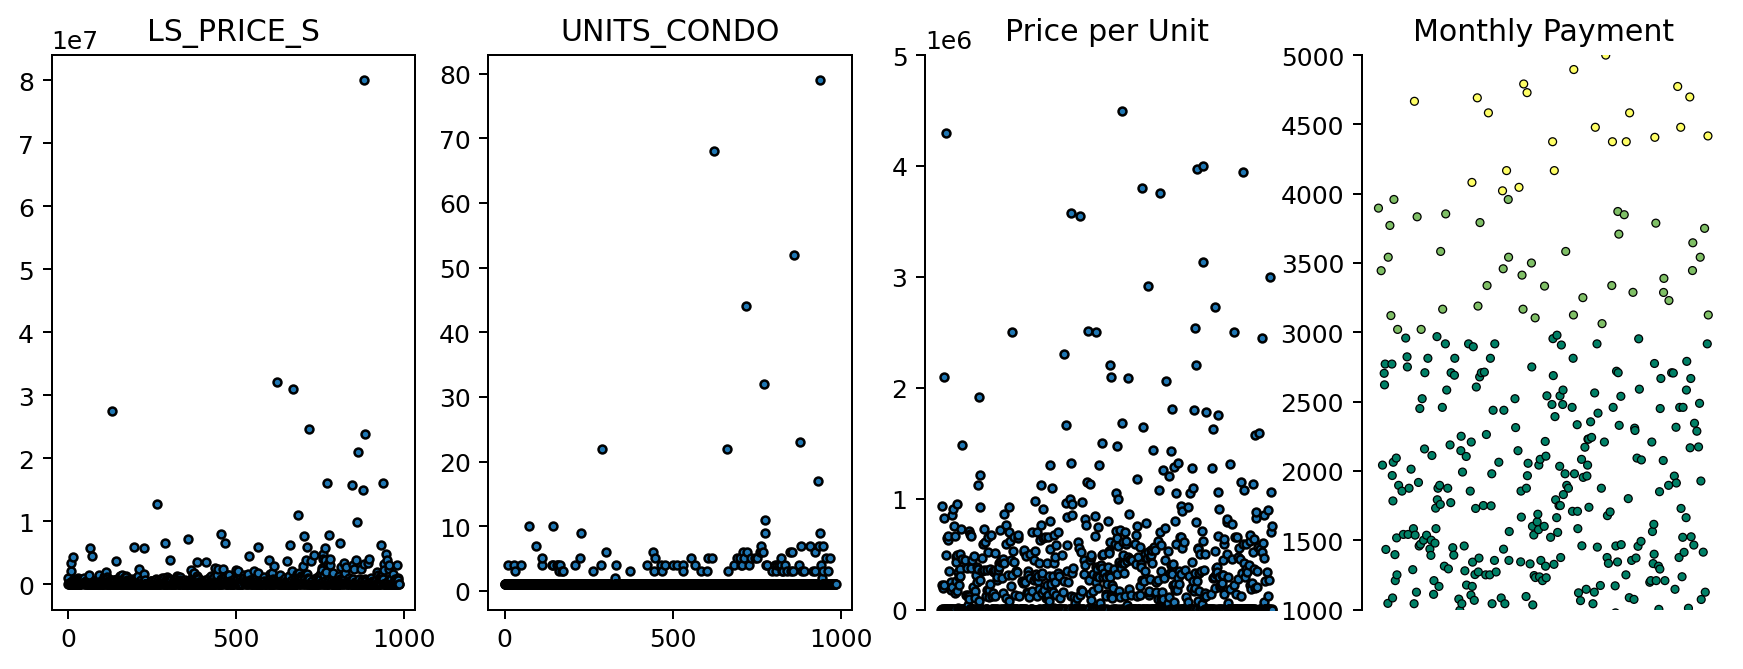

In [16]:
# METRIC: Price per Unit

colnames = ['LS_PRICE_S', 'UNITS_CONDO']

# Convert types
df_tmp = df_parcels.copy()
for colname in colnames:
    df_tmp[colname] = pd.to_numeric(df_tmp[colname], errors='coerce')

# Drop invalid vals
print('DROP NANs:')
for colname in colnames:
    print(pd.isna(df_tmp[colname]).sum())
    
print(f'Old Len: {len(df_tmp)}')
df_tmp = df_tmp.dropna(subset=colnames)


# Drop vals not in dict_zip2hood
df_tmp = df_tmp[df_tmp['ZIP'].isin(list(dict_zip2hood.keys()))]
print(f'New Len: {len(df_tmp)}')

# Add neighborhoods for later
df_tmp['hood'] = [dict_zip2hood[azip] for azip in df_tmp['ZIP']]

print('\nZEROS:')
for colname in colnames:
    print(pd.isna(df_tmp[colname]).sum())

pltdata = [np.array([float(i) for i in df_tmp[colname]]) for colname in colnames]

# DO SOME CALCULATIONS
pltdata.append(pltdata[0]/pltdata[1]) # price
pltdata.append(pltdata[0]/pltdata[1]/(20*12)) # monthly over 20 years, monthly

cdata_metric = pltdata[-1]

# Colorbar things
ccm = plt.cm.summer
ccm_list = [ccm(i) for i in range(ccm.N)]
ccm2 = mpl.colors.LinearSegmentedColormap.from_list('Custom cmap', ccm_list, ccm.N)
hu_psqft_bounds = np.array([0,3000,4000,5000])
ccm2_norm = mpl.colors.BoundaryNorm(hu_psqft_bounds,ccm2.N)

# Plot Data
fh,axs = plt.subplots(1,len(pltdata),figsize=(12,4),dpi=180)
for iax in range(len(axs)):
    ax = axs[iax]
    if iax==len(axs)-1:
        sc=ax.scatter(np.arange(len(pltdata[iax][0::100])), pltdata[iax][0::100], \
                     s=10, edgecolor='k', linewidths=0.5, \
                     c=pltdata[iax][0::100], cmap=ccm2, norm=ccm2_norm)
    else:
        sc=ax.scatter(np.arange(len(pltdata[iax][0::100])), pltdata[iax][0::100], \
                     s=10, edgecolor='k')
    if iax<len(colnames):
        ax.set_title(colnames[iax])

axs[-2].set_ylim((0,5e6))
axs[-2].spines['top'].set_visible(False)
axs[-2].spines['right'].set_visible(False)
axs[-2].spines['bottom'].set_visible(False)
axs[-2].get_xaxis().set_visible(False)
axs[-2].set_title('Price per Unit')

axs[-1].set_ylim((1e3,5e3))
axs[-1].spines['top'].set_visible(False)
axs[-1].spines['right'].set_visible(False)
axs[-1].spines['bottom'].set_visible(False)
axs[-1].get_xaxis().set_visible(False)
axs[-1].set_title('Monthly Payment')

plt.show()

In [17]:
tmp = pltdata[-1]
cond = np.logical_and(tmp>2000,tmp<3000)
print(f'Properties: {len(tmp)}')
print(f'Properties in condition: {sum(cond)}')
len(tmp[cond])/len(tmp)

Properties: 98422
Properties in condition: 8734


0.08874032228566783

[56.79478161 28.7075526  14.49766579]
[2000 3000 4000 5000]


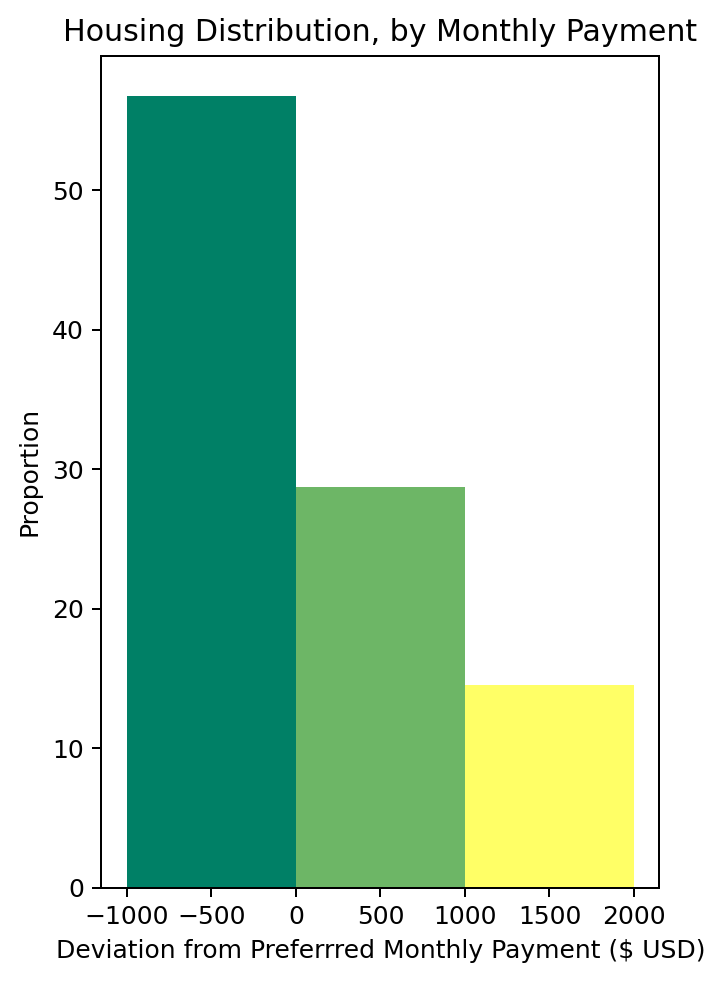

In [18]:
hu_psqft_bounds = np.array([2000,3000,4000,5000])
barctrs = np.array([0,1500,3500,4500])/3500
barx = np.array([-500,500,1500])

hist,edges = np.histogram(pltdata[-1], hu_psqft_bounds)
hist = hist/hist.sum()*100
barcolors = [np.array(ccm(val)[:3]) for val in barctrs]

#print(barctrs)
#print(barcolors)
print(hist)
print(edges)

fh,ax = plt.subplots(1,1,figsize=(4,6),dpi=180)
bc = ax.bar(barx, hist, color=barcolors, width=1000)
#bc = ax.bar(hu_psqft_bounds[:-1], cdata_histo, color=barcolors, width=1)
#ax.set_ylim((0,0.7))
ax.set_ylabel('Proportion')
ax.set_xlabel('Deviation from Preferrred Monthly Payment ($ USD)')
#ax.set_xlabel(f'${{{sqft_norms[iax]}}}\\times 10^x$')
ax.set_title('Housing Distribution, by Monthly Payment', fontsize=12)



plt.show()

In [19]:
#pltdata[iax].shape
cond = np.logical_and(pltdata[iax]>4000, pltdata[iax]<5000)
print(f'Num of parcels: {cond.sum()}')
filtval = np.sum(df_tmp['UNITS_CONDO'].iloc[cond].values)
print(f'Num of units: {filtval.sum()}')

Num of parcels: 2057
Num of units: 4369.0


### Assign parcel data to zipcode (multiple parcels per zip), then to neighborhood (multiple zips per neighborhood)

In [20]:
hoodblobs = []
hoodmasks = []

for ahood in df_tmp['hood'].values.unique():
    hoodmask = df_tmp['hood'].isin([ahood])
    hoodcentroid = gpdf_hoods[gpdf_hoods['blockgr2020_ctr_neighb_name'].isin([ahood])].geometry.centroid
    hoodcoords = [hoodcentroid.values.x[0], hoodcentroid.values.y[0]]
    hoodblobs.append([np.random.normal(loc=acoord, scale=.003, size=(hoodmask.sum())) for acoord in hoodcoords])
    hoodmasks.append(hoodmask.values)
    print(f'{ahood}: {hoodmask.sum()}; centroid {hoodcoords}')
    

Dorchester: 22984; centroid [np.float64(-71.06205363673868), np.float64(42.298489160644095)]
Allston: 2192; centroid [np.float64(-71.12909036921103), np.float64(42.357573981675195)]
West Roxbury: 9570; centroid [np.float64(-71.16082850881169), np.float64(42.28138407206509)]
Mattapan: 4486; centroid [np.float64(-71.091392868666), np.float64(42.27698669287458)]
East Boston: 6501; centroid [np.float64(-71.01550282035222), np.float64(42.37158423797645)]
Mission Hill: 1357; centroid [np.float64(-71.10244704598593), np.float64(42.331727646586685)]
Hyde Park: 8134; centroid [np.float64(-71.1273163542729), np.float64(42.256154731230815)]
Roslindale: 6960; centroid [np.float64(-71.1263437139989), np.float64(42.28324279501762)]
Roxbury: 4803; centroid [np.float64(-71.08574919988324), np.float64(42.31913001339604)]
Jamaica Plain: 6386; centroid [np.float64(-71.11441445412538), np.float64(42.30916500581407)]
Back Bay: 2187; centroid [np.float64(-71.08110059814649), np.float64(42.34951608718771)]
S

/tmp/ipykernel_55738/3995470090.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hoodcentroid = gpdf_hoods[gpdf_hoods['blockgr2020_ctr_neighb_name'].isin([ahood])].geometry.centroid
/tmp/ipykernel_55738/3995470090.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hoodcentroid = gpdf_hoods[gpdf_hoods['blockgr2020_ctr_neighb_name'].isin([ahood])].geometry.centroid
/tmp/ipykernel_55738/3995470090.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hoodcentroid = gpdf_hoods[gpdf_hoods['blockgr2020_ctr_neighb_name'].isin([ahood])].geometry.centroid
/tmp/ipykernel_55738/3

### Show data clustered at neighborhood centroids (for wireframe only)

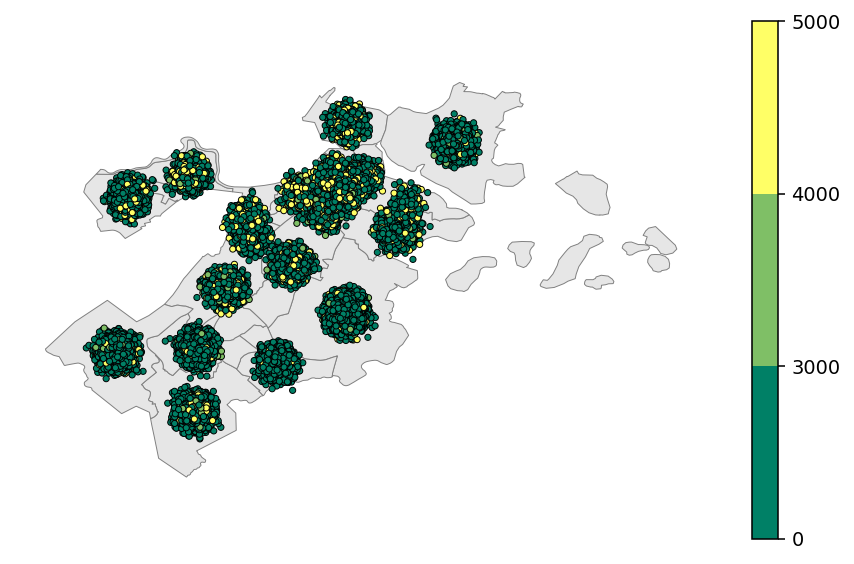

In [21]:
fh,ax = plt.subplots(1,1,figsize=(8,8),dpi=140)

cdatas = []
cdatas_mean = []
for ii,ahood in enumerate(df_tmp['hood'].values.unique()):
    cdata = cdata_metric
    cdata = cdata[hoodmasks[ii]]
    cdatas.append(cdata)
    cdatas_mean.append(cdata.mean())
cdatas_mean = np.array(cdatas_mean)

gpdf_hoods.plot(ax=ax, \
                facecolor=np.array([1,1,1])*0.9, \
                edgecolor=np.array([1,1,1])*0.5, \
                linewidth=0.5)
#sc = ax.scatter(centpts[:,0], centpts[:,1], c='k', s=5)
for ii,ablob in enumerate(hoodblobs):
    sc = ax.scatter(hoodblobs[ii][0], hoodblobs[ii][1], \
                    s=10, edgecolor='k', linewidths=0.5, \
                    c=cdatas[ii], cmap=ccm2, norm=ccm2_norm)
    
fh.colorbar(sc, orientation='vertical', shrink=0.6)
ax.grid(alpha=0.3)

ax.set_aspect('equal')
ax.set_axis_off()

#plt.show()

fh.savefig('out.png', transparent=True)

In [22]:
gpdf_combined = gpdf_hoods.copy()
gpdf_combined.insert(2,'cdata',0.0)

for ii,ahood in enumerate(df_tmp['hood'].values.unique()):
    rowidx = np.where(gpdf_combined['blockgr2020_ctr_neighb_name'].isin([ahood]))[0][0]
    colidx = gpdf_combined.columns.get_loc('cdata')
    gpdf_combined.iat[rowidx,colidx] = cdatas_mean[ii]

#gpdf_combined

### Show average data by neighborhood (collect points to average)

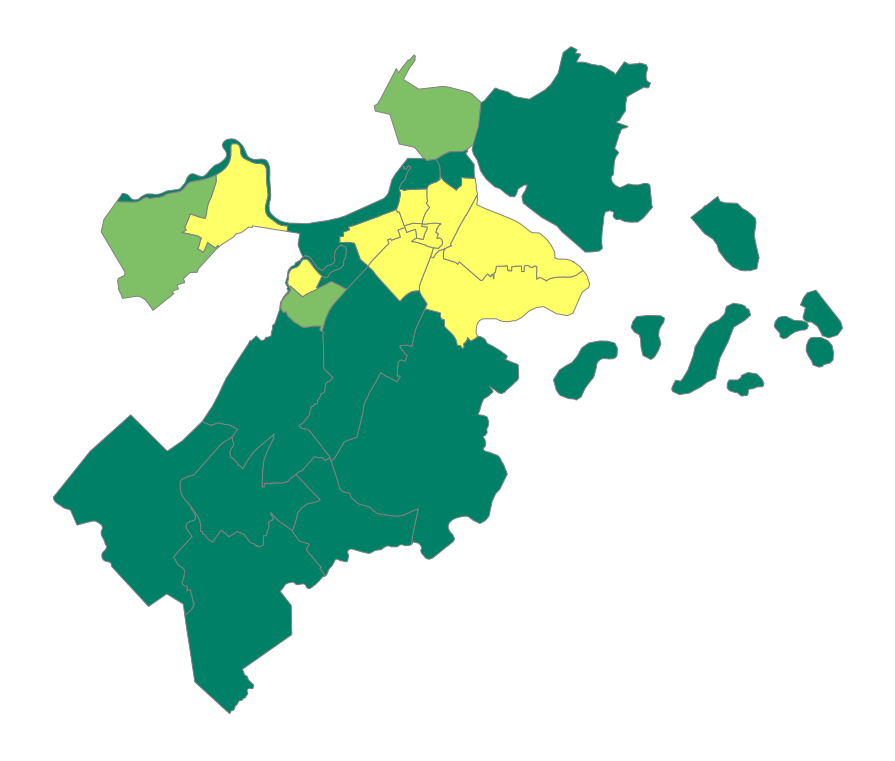

In [23]:
fh,ax = plt.subplots(1,1,figsize=(8,8),dpi=140)
gpdf_combined.plot(ax=ax, \
                column='cdata', \
                edgecolor=np.array([1,1,1])*0.5, \
                linewidth=0.5, \
                cmap=ccm2, norm=ccm2_norm)

ax.set_axis_off()

#plt.show()

fh.savefig('out.png', transparent=True)

# **OTHER METRICS**

## METRIC: Residential Area per Lot Size (cramped-ness?)

DROP NANs:
7694
28803
Old Len: 851676
New Len: 822873

ZEROS:
0
0


/tmp/ipykernel_55738/2877745444.py:25: RuntimeWarning: divide by zero encountered in divide
  pltdata.append(pltdata[0]/pltdata[1]*1000)


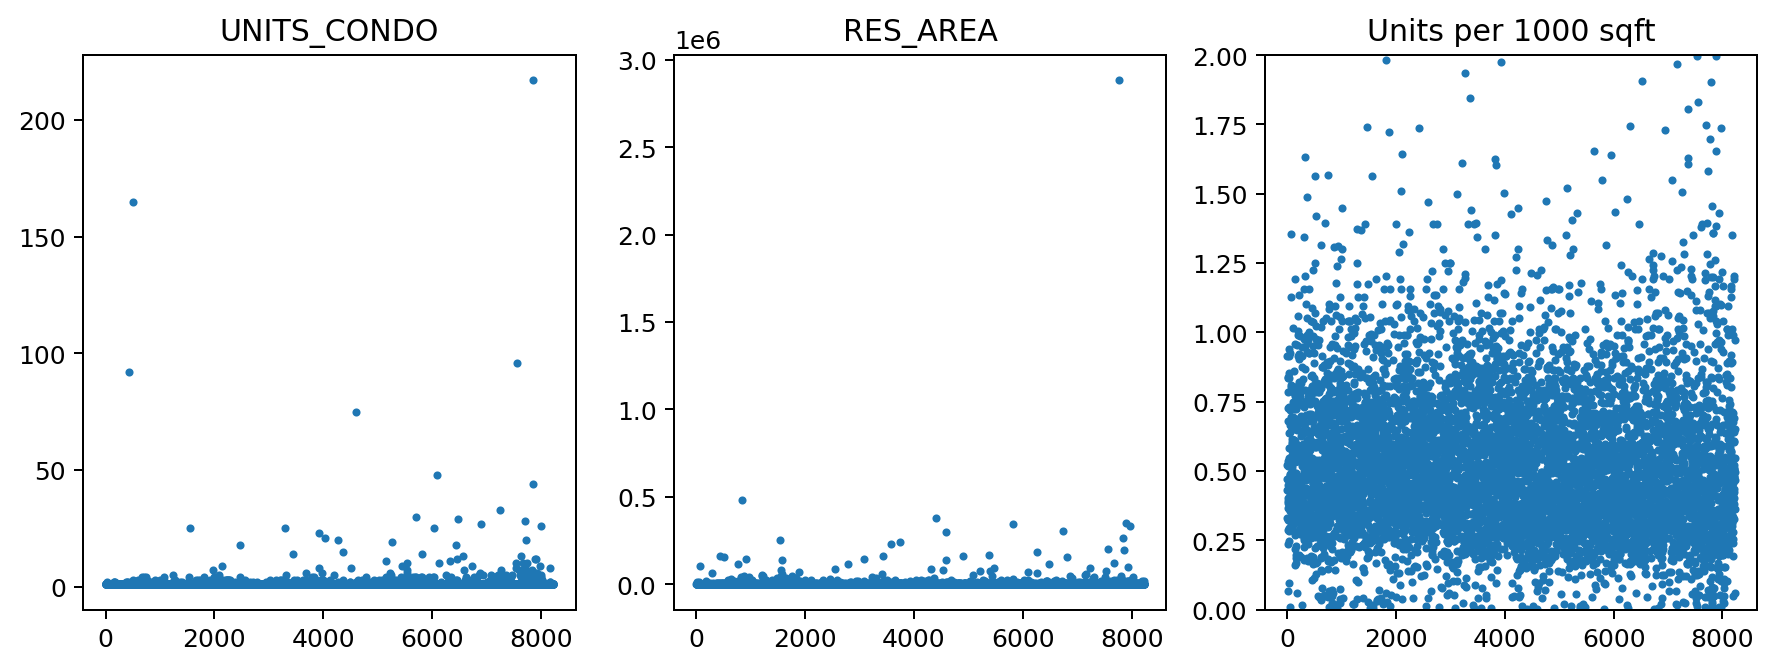

In [24]:
# METRIC: units per 1000sqft of residential space

colnames = ['UNITS_CONDO', 'RES_AREA']

# Convert types
df_tmp = df_parcels.copy()
for colname in colnames:
    df_tmp[colname] = pd.to_numeric(df_tmp[colname], errors='coerce')

# Drop invalid vals
print('DROP NANs:')
for colname in colnames:
    print(pd.isna(df_tmp[colname]).sum())
    
print(f'Old Len: {len(df_tmp)}')
df_tmp = df_tmp.dropna(subset=colnames)
print(f'New Len: {len(df_tmp)}')

print('\nZEROS:')
for colname in colnames:
    print(pd.isna(df_tmp[colname]).sum())

pltdata = [np.array([float(i) for i in df_tmp[colname]]) for colname in colnames]

pltdata.append(pltdata[0]/pltdata[1]*1000)

# Plot Data
fh,axs = plt.subplots(1,len(pltdata),figsize=(12,4),dpi=180)
for iax in range(len(axs)):
    ax = axs[iax]
    sc=ax.scatter(np.arange(len(pltdata[iax][0::100])), pltdata[iax][0::100], \
                 s=5)
    if iax<len(colnames):
        ax.set_title(colnames[iax])

axs[2].set_ylim((0,2))
axs[2].set_title('Units per 1000 sqft')

plt.show()

DROP NANs:
28803
8318
144725
Old Len: 851676
New Len: 696320

ZEROS:
0
0
0


/tmp/ipykernel_55738/404819917.py:25: RuntimeWarning: divide by zero encountered in divide
  pltdata.append(pltdata[0]/pltdata[1])
/tmp/ipykernel_55738/404819917.py:25: RuntimeWarning: invalid value encountered in divide
  pltdata.append(pltdata[0]/pltdata[1])


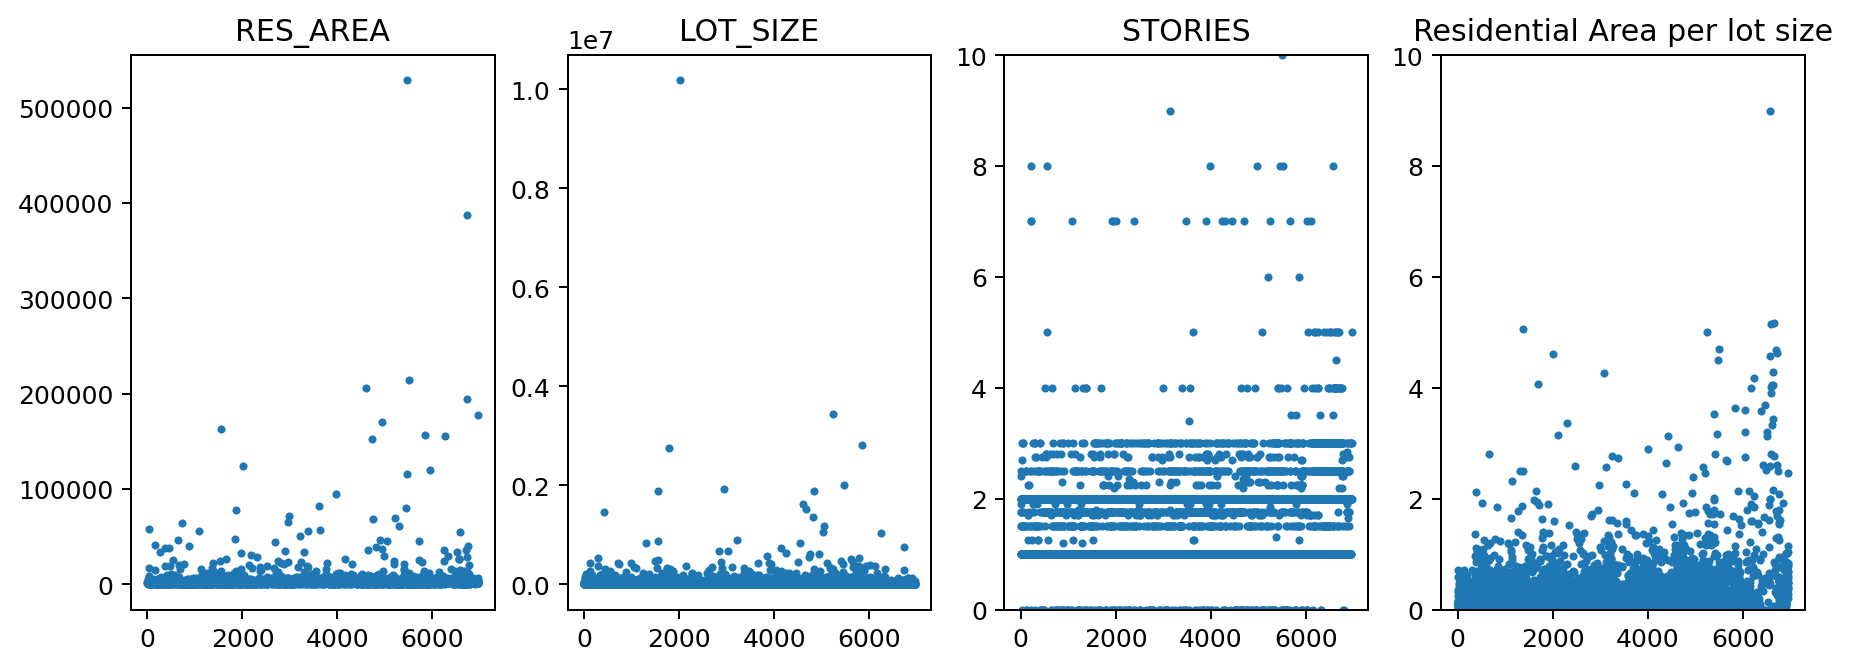

In [25]:
# METRIC: Residential Area per Lot Size (cramped-ness?)

colnames = ['RES_AREA', 'LOT_SIZE', 'STORIES']

# Convert types
df_tmp = df_parcels.copy()
for colname in colnames:
    df_tmp[colname] = pd.to_numeric(df_tmp[colname], errors='coerce')

# Drop invalid vals
print('DROP NANs:')
for colname in colnames:
    print(pd.isna(df_tmp[colname]).sum())
    
print(f'Old Len: {len(df_tmp)}')
df_tmp = df_tmp.dropna(subset=colnames)
print(f'New Len: {len(df_tmp)}')

print('\nZEROS:')
for colname in colnames:
    print(pd.isna(df_tmp[colname]).sum())

pltdata = [np.array([float(i) for i in df_tmp[colname]]) for colname in colnames]

pltdata.append(pltdata[0]/pltdata[1])

# Plot Data
fh,axs = plt.subplots(1,len(pltdata),figsize=(12,4),dpi=180)
for iax in range(len(axs)):
    ax = axs[iax]
    sc=ax.scatter(np.arange(len(pltdata[iax][0::100])), pltdata[iax][0::100], \
                 s=5)
    if iax<len(colnames):
        ax.set_title(colnames[iax])

axs[-2].set_ylim((0,10))

axs[-1].set_ylim((0,10))
axs[-1].set_title('Residential Area per lot size')

plt.show()

## METRIC: Housing Units per Unit Area

In [26]:
# HOUSING DEVELOPMENT
df_housdev = pd.read_csv(os.path.join(datadir,'massbuilds/massbuilds_housing_development.csv'))
print(len(df_housdev))
print(df_housdev.columns)
df_housdev.head()

3994
Index(['id', 'user_id', 'rdv', 'asofright', 'ovr55', 'clusteros', 'phased',
       'stalled', 'name', 'status', 'descr', 'prj_url', 'address', 'state',
       'zip_code', 'height', 'stories', 'year_compl', 'prjarea', 'singfamhu',
       'smmultifam', 'lgmultifam', 'hu', 'gqpop', 'rptdemp', 'commsf',
       'hotelrms', 'onsitepark', 'total_cost', 'ret_sqft', 'ofcmd_sqft',
       'indmf_sqft', 'whs_sqft', 'rnd_sqft', 'ei_sqft', 'other_sqft',
       'hotel_sqft', 'latitude', 'longitude', 'mixed_use', 'created_at',
       'updated_at', 'municipal', 'devlper', 'yrcomp_est', 'units_1bd',
       'units_2bd', 'units_3bd', 'affrd_unit', 'aff_u30', 'aff_30_50',
       'aff_50_80', 'aff_80p', 'headqtrs', 'park_type', 'publicsqft',
       'unknownhu', 'aff_unknown', 'unk_sqft', 'loc_id', 'parcel_fy',
       'rpa_name', 'county', 'nhood', 'n_transit', 'mepa_id',
       'traffic_count_data', 'mepa_id_present', 'traffic_count_data_present'],
      dtype='str')


,id,user_id,rdv,asofright,ovr55,clusteros,phased,stalled,name,status,...,loc_id,parcel_fy,rpa_name,county,nhood,n_transit,mepa_id,traffic_count_data,mepa_id_present,traffic_count_data_present
0,538,344.0,True,False,False,False,False,False,RCG East Mill,completed,...,M_230839_939019,2013.0,Merrimack Valley Planning Commission,Essex,NaN,"[""RTA: LRTA"", ""RTA: MVRTA""]",NaN,NaN,NaN,NaN
1,539,344.0,False,False,False,False,False,False,Bradstreet on Main,completed,...,F_752294_3065224,2016.0,Merrimack Valley Planning Commission,Essex,NaN,"[""Commuter Rail: Andover""]",NaN,NaN,NaN,NaN
2,2175,1.0,False,False,False,False,False,False,Lowland Farms,completed,...,M_258682_930783,2018.0,Metropolitan Area Planning Council,Essex,NaN,[],NaN,NaN,NaN,NaN
3,738,1.0,True,False,False,False,False,False,450 Cambridge Street,completed,...,M_230015_900450,2017.0,Metropolitan Area Planning Council,Suffolk,Allston,"[""Rapid Transit: Harvard Avenue""]",NaN,NaN,NaN,NaN
4,4,362.0,True,False,False,False,False,False,201 West Brookline Street,completed,...,M_234908_899298,2017.0,Metropolitan Area Planning Council,Suffolk,South End,"[""Rapid Transit: Back Bay""]",NaN,NaN,NaN,NaN


In [27]:
# Data
hu_psqft = df_housdev['hu']/df_housdev['commsf']

In [28]:
# Coordinate data
plotdata_coords = np.array([df_housdev['latitude'].values, df_housdev['longitude'].values])

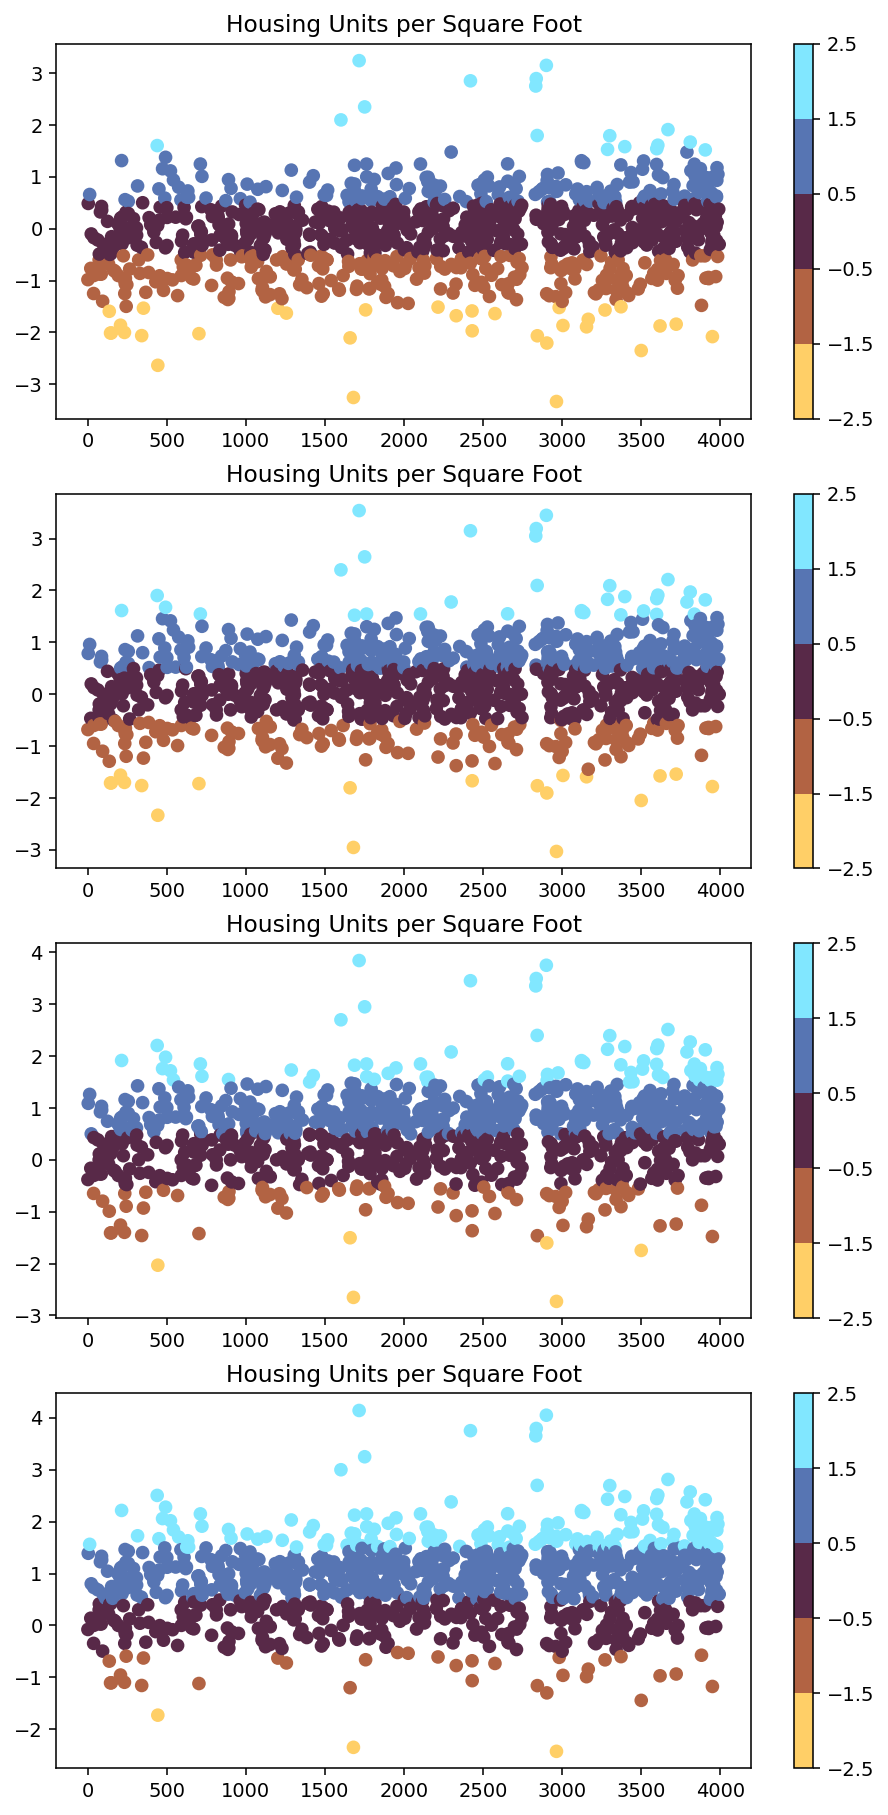

In [29]:
sqft_norms = [125,250,500,1000]

fh,axs = plt.subplots(len(sqft_norms),1,figsize=(8,4*len(sqft_norms)),dpi=140)

ccm = plt.cm.managua
ccm_list = [ccm(i) for i in range(ccm.N)]
ccm2 = mpl.colors.LinearSegmentedColormap.from_list('Custom cmap', ccm_list, ccm.N)
hu_psqft_bounds = np.array([-2.5,-1.5,-0.5,0.5,1.5,2.5])
ccm2_norm = mpl.colors.BoundaryNorm(hu_psqft_bounds,ccm2.N)

pltdata = [np.log10(hu_psqft*val) for val in sqft_norms]

for iax in range(len(axs)):
    ax = axs[iax]
    sc=ax.scatter(np.arange(len(pltdata[iax])), pltdata[iax], \
                  c=pltdata[iax], cmap=ccm2, norm=ccm2_norm)
    fh.colorbar(sc)
    ax.set_title('Housing Units per Square Foot')

plt.show()

In [30]:
hu_psqft_histos = []

for ii in range(len(pltdata)):
    hist,edges = np.histogram(pltdata[ii], hu_psqft_bounds)
    hu_psqft_histos.append(hist/hist.sum())

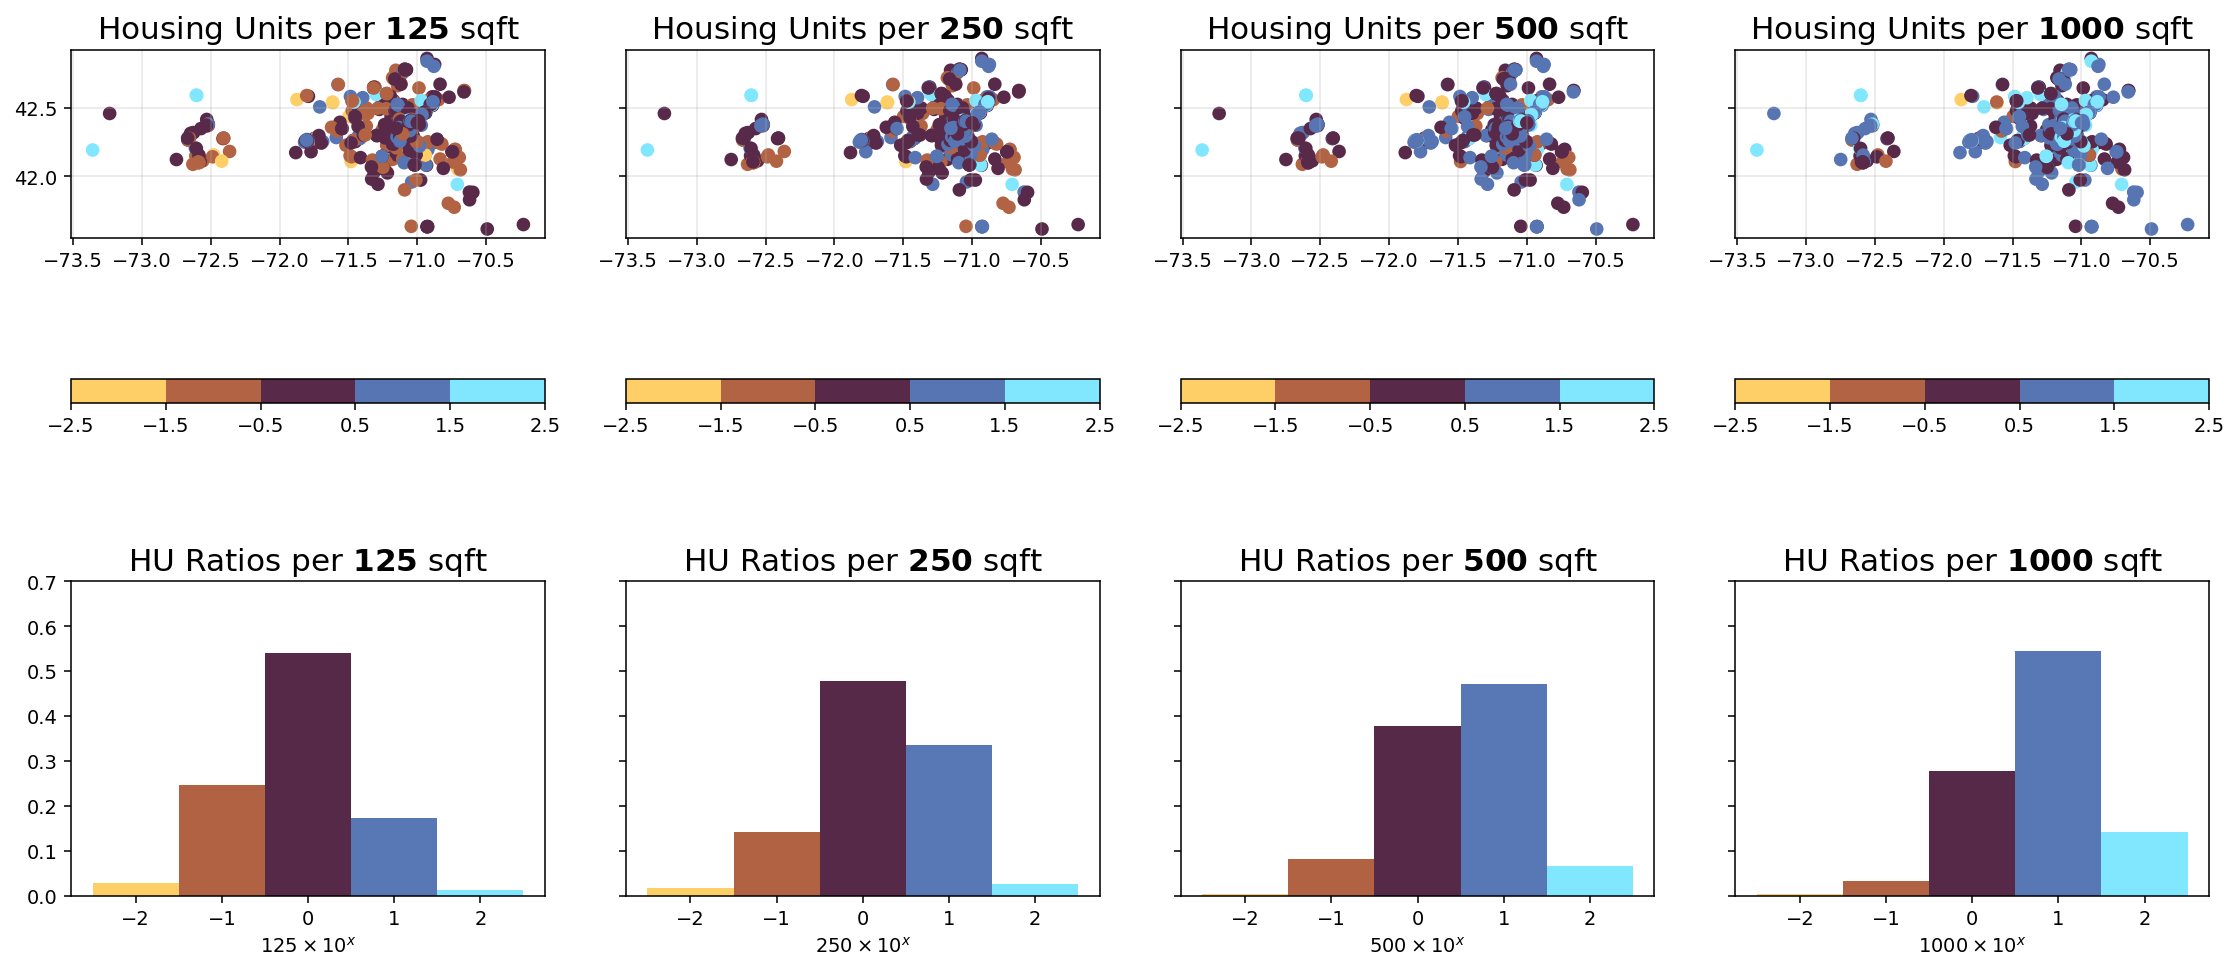

In [31]:
pltdata = [np.log10(hu_psqft*val) for val in sqft_norms]
barctrs = np.linspace(0,1,5)
barcolors = [np.array(ccm(val)[:3]) for val in barctrs]

fh,axs = plt.subplots(2,len(pltdata), \
                      gridspec_kw={'height_ratios': [3,1]}, \
                      figsize=(4*len(pltdata),10),dpi=140)
plt.tight_layout()

for iax in range(len(pltdata)):
    
    # SPATIAL MAP
    ax = axs[0][iax]
    sc = ax.scatter(plotdata_coords[1,:], plotdata_coords[0,:], \
                  c=pltdata[iax], cmap=ccm2, norm=ccm2_norm)
    fh.colorbar(sc, orientation='horizontal')
    ax.set_aspect('equal', 'box')
    ax.grid(alpha=0.3)
    ax.set_title(f'Housing Units per $\\bf{{{sqft_norms[iax]}}}$ sqft', fontsize=16)
    if iax>0:
        plt.setp(ax.get_yticklabels(), visible=False)


    # BAR CHART
    ax = axs[1][iax]
    bc = ax.bar(hu_psqft_bounds[:-1]+0.5, hu_psqft_histos[iax], color=barcolors, \
               width=1)
    ax.set_ylim((0,0.7))
    ax.set_xlabel(f'${{{sqft_norms[iax]}}}\\times 10^x$')
    ax.set_title(f'HU Ratios per $\\bf{{{sqft_norms[iax]}}}$ sqft', fontsize=16)
    if iax>0:
        plt.setp(ax.get_yticklabels(), visible=False)

plt.show()

# **Unused**

In [32]:
# RANDOM CLUSTERS
"""
fh,axs = plt.subplots(1,2,figsize=(12,4),dpi=180)

clust1 = [np.random.normal(loc=0, scale=1, size=(3000)) for i in range(2)]
sc=axs[0].scatter(clust1[0], clust1[1], s=10, edgecolor='k')
axs[0].set_aspect('equal')


clust2 = [np.random.normal(loc=0, scale=1, size=(3000)) for i in range(2)]
sc=axs[1].scatter(clust2[0], clust2[1], s=10, edgecolor='k', color=[0.9,0.3,0.2])
axs[1].set_aspect('equal')


plt.show()
"""


"\nfh,axs = plt.subplots(1,2,figsize=(12,4),dpi=180)\n\nclust1 = [np.random.normal(loc=0, scale=1, size=(3000)) for i in range(2)]\nsc=axs[0].scatter(clust1[0], clust1[1], s=10, edgecolor='k')\naxs[0].set_aspect('equal')\n\n\nclust2 = [np.random.normal(loc=0, scale=1, size=(3000)) for i in range(2)]\nsc=axs[1].scatter(clust2[0], clust2[1], s=10, edgecolor='k', color=[0.9,0.3,0.2])\naxs[1].set_aspect('equal')\n\n\nplt.show()\n"

In [33]:
"""
gpdf2.explore( \
    height=500, width=500, \
    column='town_id', \
    tooltip=False, \
    legend=True, \
    tiles='CartoDB positron', \
    edgecolors='k', \
    scheme='EqualInterval', \
    map_kwds=dict(scrollWheelZoom=False))
"""

"\ngpdf2.explore(     height=500, width=500,     column='town_id',     tooltip=False,     legend=True,     tiles='CartoDB positron',     edgecolors='k',     scheme='EqualInterval',     map_kwds=dict(scrollWheelZoom=False))\n"

In [34]:
"""
gpdf_geoids.explore( \
    height=500, width=500, \
    tooltip=False, \
    legend=True, \
    tiles='CartoDB positron', \
    edgecolors='k', \
    scheme='EqualInterval', \
    map_kwds=dict(scrollWheelZoom=False))
"""

"\ngpdf_geoids.explore(     height=500, width=500,     tooltip=False,     legend=True,     tiles='CartoDB positron',     edgecolors='k',     scheme='EqualInterval',     map_kwds=dict(scrollWheelZoom=False))\n"